# 1D Non-Overlapping Domain Decomposition — PINN
## SRIP 2026 — IIT Gandhinagar | DD-ANN Phase 4

---

## Overlapping vs Non-Overlapping: Key Differences

| Aspect | Overlapping (Schwarz) | **Non-Overlapping** |
|--------|----------------------|---------------------|
| Subdomains | $\Omega_1=[0,b]$, $\Omega_2=[a,1]$ with $a<b$ | $\Omega_1=[0,\gamma]$, $\Omega_2=[\gamma,1]$ — share only the interface point |
| Interface | Two points $a$ and $b$ define a shared region | Single interface point $\gamma$ |
| Matching condition | Value of one network at the other's boundary | **Both value AND flux** must match: $u_1(\gamma)=u_2(\gamma)$ and $u_1'(\gamma)=u_2'(\gamma)$ |
| Information exchange | Only Dirichlet (value) transferred | Dirichlet + Neumann (flux) transferred |
| Method name | Schwarz Alternating | **Dirichlet–Neumann Iteration** |
| Convergence | Usually faster (more info shared via overlap) | Requires flux matching — more physically accurate |

---

## The Dirichlet–Neumann Algorithm

Split $[0,1]$ at interface $\gamma = 0.5$ into:
- $\Omega_1 = [0,\, \gamma]$ — left subdomain
- $\Omega_2 = [\gamma,\, 1]$ — right subdomain

At each iteration $k$:

**Step 1 — Train PINN₁** on $\Omega_1$ with:
- Left BC: $u_1(0) = u_0$ (fixed)  
- Right BC (Dirichlet): $u_1(\gamma) = \lambda^{(k)}$ (current interface value guess)

**Step 2 — Extract flux from PINN₁:** compute $u_1'(\gamma)$ via autodiff

**Step 3 — Train PINN₂** on $\Omega_2$ with:
- Left BC (Neumann relaxation): enforce $u_2(\gamma) \approx \lambda^{(k)}$ and flux $u_2'(\gamma) \approx u_1'(\gamma)$
- Right BC: $u_2(1) = u_1$ (fixed)

**Step 4 — Update interface:**
$$\lambda^{(k+1)} = \theta \cdot u_2(\gamma) + (1-\theta) \cdot \lambda^{(k)}$$
where $\theta \in (0,1]$ is a relaxation parameter.

**Convergence check:** $|\lambda^{(k+1)} - \lambda^{(k)}| < \epsilon$

---

## Four Test Problems

| Problem | PDE | Exact $u(x)$ | BCs |
|---------|-----|-------------|-----|
| 1 | $-u'' = \pi^2\sin(\pi x)$ | $\sin(\pi x)$ | $u(0)=0,\ u(1)=0$ |
| 2 | $-u'' = 2$ | $x(1-x)$ | $u(0)=0,\ u(1)=0$ |
| 3 | $-u'' = 4\pi^2\sin(2\pi x)$ | $\sin(2\pi x)$ | $u(0)=0,\ u(1)=0$ |
| 4 | $-u'' = -e^x$ | $e^x$ | $u(0)=1,\ u(1)=e$ |

## Section 1 — Imports & Reproducibility

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

torch.manual_seed(42)
np.random.seed(42)
print(f"PyTorch version: {torch.__version__}")
print("Seeds fixed. Ready.")

PyTorch version: 2.12.0+cpu
Seeds fixed. Ready.


## Section 2 — Network Architecture & Derivative Utilities

Same 3-hidden-layer MLP as the overlapping notebook.
The key new utility is `flux_at_interface` — it computes $u'(\gamma)$ via autodiff,
which is the Neumann data passed from PINN₁ to PINN₂.

In [2]:
def create_model():
    """3 × 32 Tanh MLP — same architecture as overlapping notebook."""
    model = nn.Sequential(
        nn.Linear(1, 32), nn.Tanh(),
        nn.Linear(32, 32), nn.Tanh(),
        nn.Linear(32, 32), nn.Tanh(),
        nn.Linear(32, 1)
    )
    # Glorot initialization
    for layer in model:
        if isinstance(layer, nn.Linear):
            nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)
    return model


def flux_at_point(model, x_val):
    """
    Compute du/dx at a single point x_val using autodiff.
    This is the Neumann data (flux) at the interface.

    Steps:
      1. Create tensor with requires_grad=True
      2. Forward pass → u
      3. Autodiff → du/dx

    Used to transfer flux from PINN₁ to PINN₂ at interface γ.
    """
    x_t = torch.tensor([[x_val]], dtype=torch.float32, requires_grad=True)
    u   = model(x_t)
    du  = torch.autograd.grad(
        u, x_t,
        grad_outputs=torch.ones_like(u),
        create_graph=False   # no need for higher-order here
    )[0]
    return du.item()


def value_at_point(model, x_val):
    """Evaluate model at a single scalar point (no grad needed)."""
    x_t = torch.tensor([[x_val]], dtype=torch.float32)
    with torch.no_grad():
        return model(x_t).item()

print("Network and utilities defined.")
print("flux_at_point() extracts Neumann data via autodiff.")

Network and utilities defined.
flux_at_point() extracts Neumann data via autodiff.


## Section 3 — Loss Function

For the non-overlapping method we need **three loss terms**:

$$\mathcal{L} = \mathcal{L}_{\text{PDE}} + \lambda_{\text{bc}} \cdot \mathcal{L}_{\text{bc}} + \lambda_{\text{flux}} \cdot \mathcal{L}_{\text{flux}}$$

- $\mathcal{L}_{\text{PDE}}$ — PDE residual at interior collocation points
- $\mathcal{L}_{\text{bc}}$ — Dirichlet conditions at both ends of the subdomain
- $\mathcal{L}_{\text{flux}}$ — Flux (Neumann) matching at the interface (only for PINN₂)

This is the key difference from the overlapping case, which only had PDE + Dirichlet losses.

In [3]:
def compute_loss(model, f_func,
                 x_interior,
                 x_bc, u_bc,
                 x_flux=None, target_flux=None,
                 lambda_bc=100.0, lambda_flux=50.0):
    """
    Compute total loss for one subdomain PINN.

    Args:
        model        : the PINN for this subdomain
        f_func       : RHS of -u'' = f(x)
        x_interior   : collocation points inside subdomain, requires_grad=True
        x_bc         : boundary/interface points, shape (2,1)
        u_bc         : target values at x_bc,        shape (2,1)
        x_flux       : interface point for flux matching (optional, only PINN₂)
        target_flux  : target du/dx value at interface (optional, only PINN₂)
        lambda_bc    : weight for Dirichlet BC loss
        lambda_flux  : weight for Neumann flux loss

    Returns:
        total_loss (tensor for backprop),
        pde_loss_val (float, for logging),
        bc_loss_val  (float, for logging),
        flux_loss_val(float, for logging)
    """
    # ── PDE residual loss ─────────────────────────────────────
    u   = model(x_interior)
    du  = torch.autograd.grad(
        u, x_interior,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]
    d2u = torch.autograd.grad(
        du, x_interior,
        grad_outputs=torch.ones_like(du),
        create_graph=True
    )[0]
    pde_loss = torch.mean((-d2u - f_func(x_interior)) ** 2)

    # ── Dirichlet BC loss ─────────────────────────────────────
    u_pred_bc = model(x_bc)
    bc_loss   = torch.mean((u_pred_bc - u_bc) ** 2)

    # ── Neumann flux loss (only for PINN₂) ───────────────────
    flux_loss = torch.tensor(0.0)
    if x_flux is not None and target_flux is not None:
        x_fl = x_flux.clone().requires_grad_(True)
        u_fl = model(x_fl)
        du_fl = torch.autograd.grad(
            u_fl, x_fl,
            grad_outputs=torch.ones_like(u_fl),
            create_graph=True
        )[0]
        flux_loss = (du_fl - target_flux) ** 2

    total = pde_loss + lambda_bc * bc_loss + lambda_flux * flux_loss

    return total, pde_loss.item(), bc_loss.item(), float(flux_loss.item() if hasattr(flux_loss, 'item') else flux_loss)

print("Loss function defined.")
print("Supports optional Neumann flux term for PINN₂.")

Loss function defined.
Supports optional Neumann flux term for PINN₂.


## Section 4 — Subdomain Training Function

Trains one PINN on one subdomain for a fixed number of epochs (or until early stopping).

The `flux_target` argument is `None` for PINN₁ and set to $u_1'(\gamma)$ for PINN₂.

In [4]:
def train_subdomain(
    model, f_func,
    x_lo, x_hi,
    x_left, u_left,
    x_right, u_right,
    flux_target=None,       # du/dx at interface — only for PINN₂
    x_interface=None,       # interface point    — only for PINN₂
    epochs=800,
    n_collocation=500,
    lambda_bc=100.0,
    lambda_flux=50.0,
    lr=1e-3,
    patience=150,
    min_delta=1e-7
):
    """
    Train a PINN on subdomain [x_lo, x_hi].

    Boundary conditions:
        u(x_left)  = u_left   (Dirichlet, left end)
        u(x_right) = u_right  (Dirichlet, right end — may be interface)

    Optional flux (Neumann) condition:
        du/dx(x_interface) = flux_target  (only for PINN₂)

    Returns:
        loss history (list), elapsed time (float)
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=200, gamma=0.9
    )

    x_bc = torch.tensor([[x_left], [x_right]], dtype=torch.float32)
    u_bc = torch.tensor([[u_left], [u_right]], dtype=torch.float32)

    # Interface tensor for flux loss (PINN₂ only)
    x_fl_tensor = None
    if x_interface is not None:
        x_fl_tensor = torch.tensor([[x_interface]], dtype=torch.float32)

    best_loss    = float('inf')
    patience_ctr = 0
    history      = []
    t0           = time.perf_counter()

    for epoch in range(epochs):
        # Resample collocation points inside the subdomain every epoch
        x_int = x_lo + (x_hi - x_lo) * torch.rand(n_collocation, 1)
        x_int.requires_grad_(True)

        total, pde_v, bc_v, flux_v = compute_loss(
            model, f_func,
            x_int,
            x_bc, u_bc,
            x_flux=x_fl_tensor,
            target_flux=flux_target,
            lambda_bc=lambda_bc,
            lambda_flux=lambda_flux
        )

        optimizer.zero_grad()
        total.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        history.append(total.item())

        # Early stopping
        if total.item() < best_loss - min_delta:
            best_loss    = total.item()
            patience_ctr = 0
        else:
            patience_ctr += 1
        if patience_ctr >= patience:
            break

    return history, time.perf_counter() - t0

print("Subdomain trainer defined.")

Subdomain trainer defined.


## Section 5 — Dirichlet–Neumann Iteration (Main DD Loop)

This is the core of the non-overlapping method.

At each iteration:
1. **PINN₁** is trained on $\Omega_1 = [0, \gamma]$ with Dirichlet BCs at both ends (left fixed, right = current $\lambda^{(k)}$)
2. **Flux extraction:** $u_1'(\gamma)$ is computed via autodiff from the trained PINN₁
3. **PINN₂** is trained on $\Omega_2 = [\gamma, 1]$ with Dirichlet BC at right end + **Neumann flux loss** at left end
4. **Interface update:** $\lambda^{(k+1)} = \theta \cdot u_2(\gamma) + (1-\theta)\lambda^{(k)}$

The relaxation parameter $\theta$ controls how aggressively the interface is updated. $\theta=1$ is full update; $\theta<1$ damps oscillations.

In [5]:
def dirichlet_neumann_dd(
    f_func,
    bc_left, bc_right,
    gamma=0.5,
    dd_iters=6,
    epochs_per_iter=800,
    n_collocation=500,
    lambda_bc=100.0,
    lambda_flux=50.0,
    lr=1e-3,
    patience=150,
    min_delta=1e-7,
    theta=1.0,           # relaxation parameter ∈ (0,1]
    verbose=True
):
    """
    Non-overlapping Domain Decomposition via Dirichlet–Neumann iteration.

    Domain: [x0, x1] split at interface γ into [x0,γ] and [γ,x1].

    Args:
        f_func        : RHS of -u'' = f(x)
        bc_left       : (x0, u0) — left global boundary
        bc_right      : (x1, u1) — right global boundary
        gamma         : interface point (default 0.5)
        dd_iters      : number of D-N iterations
        epochs_per_iter: training epochs per subdomain per iteration
        lambda_bc     : Dirichlet BC penalty weight
        lambda_flux   : Neumann flux penalty weight (for PINN₂)
        theta         : relaxation parameter for interface update
        verbose       : print progress

    Returns:
        net1, net2    : trained PINNs for Ω₁ and Ω₂
        interface_log : list of dicts with per-iteration interface data
        total_time    : total training time (s)
        loss_history  : dict with 'omega1', 'omega2' loss lists
    """
    x0, u0 = bc_left
    x1, u1 = bc_right

    # Networks created ONCE and warm-started across iterations
    # (same as overlapping notebook — no re-initialization per iter)
    net1 = create_model()
    net2 = create_model()

    # Initial interface value guess — linear interpolation
    frac = (gamma - x0) / (x1 - x0)
    lam  = u0 + frac * (u1 - u0)  # λ⁽⁰⁾

    interface_log = []
    loss_history  = {'omega1': [], 'omega2': []}
    total_time    = 0.0

    for it in range(dd_iters):
        if verbose:
            print(f"\n── D-N Iteration {it+1}/{dd_iters}  (λ = {lam:.6f}) ──")

        # ─────────────────────────────────────────────────────
        # STEP 1: Train PINN₁ on Ω₁ = [x0, γ]
        #   Left BC  : u₁(x0) = u0  (fixed global BC)
        #   Right BC : u₁(γ)  = λ   (current Dirichlet interface value)
        #   No flux term for PINN₁
        # ─────────────────────────────────────────────────────
        h1, t1 = train_subdomain(
            net1, f_func,
            x_lo=x0, x_hi=gamma,
            x_left=x0,  u_left=u0,
            x_right=gamma, u_right=lam,
            flux_target=None, x_interface=None,
            epochs=epochs_per_iter,
            n_collocation=n_collocation,
            lambda_bc=lambda_bc,
            lambda_flux=lambda_flux,
            lr=lr, patience=patience, min_delta=min_delta
        )
        loss_history['omega1'].append(h1)
        total_time += t1

        # ─────────────────────────────────────────────────────
        # STEP 2: Extract Neumann data (flux) from PINN₁ at γ
        #   This is the Neumann data passed to PINN₂
        # ─────────────────────────────────────────────────────
        flux_gamma = flux_at_point(net1, gamma)
        u1_at_gamma = value_at_point(net1, gamma)

        if verbose:
            print(f"  PINN₁ ({len(h1)} epochs, {t1:.2f}s) | ")
            print(f"    u₁(γ) = {u1_at_gamma:.6f}  |  u₁'(γ) = {flux_gamma:.6f}  |  loss = {h1[-1]:.2e}")

        # ─────────────────────────────────────────────────────
        # STEP 3: Train PINN₂ on Ω₂ = [γ, x1]
        #   Left BC  : u₂(γ)  = λ           (Dirichlet — match interface value)
        #   Right BC : u₂(x1) = u1           (fixed global BC)
        #   Flux term: u₂'(γ) ≈ flux_gamma   (Neumann — match flux from PINN₁)
        # ─────────────────────────────────────────────────────
        h2, t2 = train_subdomain(
            net2, f_func,
            x_lo=gamma, x_hi=x1,
            x_left=gamma, u_left=lam,
            x_right=x1,  u_right=u1,
            flux_target=flux_gamma,
            x_interface=gamma,
            epochs=epochs_per_iter,
            n_collocation=n_collocation,
            lambda_bc=lambda_bc,
            lambda_flux=lambda_flux,
            lr=lr, patience=patience, min_delta=min_delta
        )
        loss_history['omega2'].append(h2)
        total_time += t2

        u2_at_gamma = value_at_point(net2, gamma)
        flux2_gamma = flux_at_point(net2, gamma)

        if verbose:
            print(f"  PINN₂ ({len(h2)} epochs, {t2:.2f}s) | ")
            print(f"    u₂(γ) = {u2_at_gamma:.6f}  |  u₂'(γ) = {flux2_gamma:.6f}  |  loss = {h2[-1]:.2e}")

        # ─────────────────────────────────────────────────────
        # STEP 4: Update interface value with relaxation
        #   λ^(k+1) = θ · u₂(γ) + (1-θ) · λ^(k)
        # ─────────────────────────────────────────────────────
        lam_new = theta * u2_at_gamma + (1.0 - theta) * lam
        value_jump = abs(u1_at_gamma - u2_at_gamma)
        flux_jump  = abs(flux_gamma  - flux2_gamma)

        if verbose:
            print(f"  Interface: |u₁-u₂| = {value_jump:.2e}  |  |u₁'-u₂'| = {flux_jump:.2e}")
            print(f"  λ update: {lam:.6f} → {lam_new:.6f}")

        interface_log.append({
            'iter'       : it + 1,
            'lambda'     : lam,
            'u1_gamma'   : u1_at_gamma,
            'u2_gamma'   : u2_at_gamma,
            'flux1_gamma': flux_gamma,
            'flux2_gamma': flux2_gamma,
            'value_jump' : value_jump,
            'flux_jump'  : flux_jump
        })

        lam = lam_new

    return net1, net2, interface_log, total_time, loss_history

print("Dirichlet-Neumann DD loop defined.")

Dirichlet-Neumann DD loop defined.


## Section 6 — Evaluation

**Stitching strategy for non-overlapping case:**

Since the two subdomains share only the single point $\gamma$ (no overlap region), the stitching is clean:
- $x < \gamma$: use PINN₁
- $x > \gamma$: use PINN₂  
- $x = \gamma$: average of both (they should agree after convergence)

This is simpler than the overlapping case where a blending zone was needed.

In [6]:
def evaluate_dd(net1, net2, exact_fn,
                gamma=0.5, x_lo=0.0, x_hi=1.0, n=400):
    """
    Evaluate non-overlapping DD solution across [x_lo, x_hi].

    Stitching:
        x < γ  → PINN₁
        x = γ  → average of PINN₁ and PINN₂
        x > γ  → PINN₂

    Returns x, u_pred, u_exact, error, metrics dict.
    """
    x = torch.linspace(x_lo, x_hi, n).unsqueeze(1)
    with torch.no_grad():
        p1 = net1(x).numpy().squeeze()
        p2 = net2(x).numpy().squeeze()

    x_np = x.numpy().squeeze()

    # Clean non-overlapping stitch
    u_pred = np.where(x_np <  gamma, p1,
             np.where(x_np >  gamma, p2,
                      0.5 * p1 + 0.5 * p2))  # exactly at γ

    u_exact = exact_fn(x).numpy().squeeze()
    error   = np.abs(u_pred - u_exact)

    rel_l2 = np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact)
    metrics = {
        'max_err' : np.max(error),
        'mean_err': np.mean(error),
        'rel_l2'  : rel_l2
    }

    print(f"  Relative L2 Error  : {rel_l2:.6f}")
    print(f"  Max Absolute Error : {metrics['max_err']:.6f}")
    print(f"  Mean Absolute Error: {metrics['mean_err']:.6f}")

    return x_np, u_pred, u_exact, error, metrics

print("Evaluation function defined.")

Evaluation function defined.


## Section 7 — Plotting

Five panels:
1. **Solution** — exact vs DD-PINN with interface marker
2. **Absolute error** — per-point error with Ω₁/Ω₂ shading
3. **Training loss** — per subdomain per D-N iteration
4. **Interface value convergence** — $u_1(\gamma)$, $u_2(\gamma)$, $\lambda^{(k)}$ vs iteration
5. **Flux convergence** — $u_1'(\gamma)$ vs $u_2'(\gamma)$ vs iteration (unique to non-overlapping)

In [7]:
def plot_dd(x, u_pred, u_exact, error,
            loss_history, interface_log,
            gamma, problem_name, elapsed):
    """
    5-panel plot for non-overlapping DD results.
    Panel 5 (flux convergence) is unique to the non-overlapping method.
    """
    fig, axs = plt.subplots(1, 5, figsize=(25, 4))
    fig.suptitle(
        f"{problem_name}  |  Interface γ={gamma}  |  Time: {elapsed:.2f}s",
        fontsize=12, fontweight='bold'
    )

    # ── Panel 1: Solution ────────────────────────────────────
    axs[0].plot(x, u_exact, 'b-',  lw=2,   label='Exact')
    axs[0].plot(x, u_pred,  'r--', lw=1.5, label='DD-PINN')
    axs[0].axvline(gamma, color='purple', lw=1.2, linestyle='-.',
                    label=f'Interface γ={gamma}')
    axs[0].axvspan(x[0], gamma,  alpha=0.07, color='steelblue',  label='Ω₁')
    axs[0].axvspan(gamma, x[-1], alpha=0.07, color='darkorange',  label='Ω₂')
    axs[0].set_title('Solution'); axs[0].set_xlabel('x')
    axs[0].legend(fontsize=7); axs[0].grid(True, linestyle=':', alpha=0.5)

    # ── Panel 2: Absolute error ───────────────────────────────
    axs[1].plot(x, error, color='crimson', lw=1.5)
    axs[1].axvline(gamma, color='purple', lw=1.0, linestyle='-.')
    axs[1].axvspan(x[0], gamma,  alpha=0.07, color='steelblue')
    axs[1].axvspan(gamma, x[-1], alpha=0.07, color='darkorange')
    axs[1].set_title('Absolute Error'); axs[1].set_xlabel('x')
    axs[1].grid(True, linestyle=':', alpha=0.5)

    # ── Panel 3: Training loss per D-N iter ───────────────────
    colors1 = plt.cm.Blues(np.linspace(0.35, 0.95, len(loss_history['omega1'])))
    colors2 = plt.cm.Oranges(np.linspace(0.35, 0.95, len(loss_history['omega2'])))
    n_iters = len(loss_history['omega1'])
    for k, (h1, h2) in enumerate(zip(loss_history['omega1'],
                                      loss_history['omega2'])):
        lbl1 = f'Ω₁ iter {k+1}' if k in (0, n_iters-1) else None
        lbl2 = f'Ω₂ iter {k+1}' if k in (0, n_iters-1) else None
        axs[2].semilogy(h1, color=colors1[k], alpha=0.85, label=lbl1)
        axs[2].semilogy(h2, color=colors2[k], alpha=0.85, label=lbl2,
                         linestyle='--')
    axs[2].set_title('Loss per D-N iter')
    axs[2].set_xlabel('Epoch'); axs[2].legend(fontsize=7)
    axs[2].grid(True, which='both', linestyle=':', alpha=0.4)

    # ── Panel 4: Interface value convergence ──────────────────
    iters = [v['iter']    for v in interface_log]
    u1g   = [v['u1_gamma'] for v in interface_log]
    u2g   = [v['u2_gamma'] for v in interface_log]
    lams  = [v['lambda']   for v in interface_log]
    axs[3].plot(iters, u1g,  'o-',  color='steelblue',  label='u₁(γ)')
    axs[3].plot(iters, u2g,  's--', color='darkorange',  label='u₂(γ)')
    axs[3].plot(iters, lams, '^:',  color='purple',      label='λ (interface guess)', alpha=0.7)
    axs[3].set_title('Interface Value Convergence')
    axs[3].set_xlabel('D-N iteration'); axs[3].legend(fontsize=7)
    axs[3].grid(True, linestyle=':', alpha=0.5)

    # ── Panel 5: Flux convergence (unique to non-overlapping) ─
    fl1 = [v['flux1_gamma'] for v in interface_log]
    fl2 = [v['flux2_gamma'] for v in interface_log]
    jmp = [v['flux_jump']   for v in interface_log]
    axs[4].plot(iters, fl1, 'o-',  color='steelblue',  label="u₁'(γ)")
    axs[4].plot(iters, fl2, 's--', color='darkorange',  label="u₂'(γ)")
    ax4b = axs[4].twinx()
    ax4b.semilogy(iters, jmp, 'D:', color='crimson',
                   alpha=0.6, label='|flux jump|')
    ax4b.set_ylabel('|flux jump| (log)', color='crimson', fontsize=8)
    axs[4].set_title('Flux Convergence at Interface')
    axs[4].set_xlabel('D-N iteration')
    axs[4].legend(fontsize=7, loc='upper left')
    ax4b.legend(fontsize=7, loc='upper right')
    axs[4].grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

print("Plotting function defined (5 panels).")

Plotting function defined (5 panels).


## Section 8 — Global Configuration

| Parameter | Value | Notes |
|-----------|-------|-------|
| `GAMMA` | 0.5 | Interface point (midpoint of domain) |
| `DD_ITERS` | 6 | Dirichlet-Neumann iterations |
| `EPOCHS_PER_ITER` | 800 | Per subdomain per iteration |
| `N_COLL` | 500 | Collocation points per subdomain |
| `LAMBDA_BC` | 100.0 | Dirichlet BC penalty |
| `LAMBDA_FLUX` | 50.0 | Neumann flux penalty (new vs overlapping) |
| `THETA` | 1.0 | Interface relaxation (1=full update, <1=damped) |

**Total epoch budget** = 2 × DD_ITERS × EPOCHS_PER_ITER = **9600** ≈ same as overlapping notebook.

In [8]:
GAMMA          = 0.5     # Interface point
DD_ITERS       = 6       # Dirichlet-Neumann iterations
EPOCHS_PER_ITER = 800    # Per subdomain per iteration
N_COLL         = 500     # Collocation points
LAMBDA_BC      = 100.0   # Dirichlet BC weight
LAMBDA_FLUX    = 50.0    # Neumann flux weight (key new parameter)
LR             = 1e-3    # Learning rate
PATIENCE       = 150     # Early stopping patience
THETA          = 1.0     # Interface relaxation parameter

timing_records = []

print("Configuration set.")
print(f"Interface at γ = {GAMMA}")
print(f"Total epoch budget = 2 × {DD_ITERS} × {EPOCHS_PER_ITER} = {2*DD_ITERS*EPOCHS_PER_ITER}")

Configuration set.
Interface at γ = 0.5
Total epoch budget = 2 × 6 × 800 = 9600


## Problem 1 — Sine Wave
$$-u'' = \pi^2\sin(\pi x), \quad u(0)=0,\ u(1)=0, \quad \text{Exact: } u(x)=\sin(\pi x)$$

The interface $\gamma=0.5$ happens to be a zero of the exact solution since $\sin(\pi/2)=1$ — wait, that's the maximum. The interface value $\lambda$ should converge to $\sin(\pi \cdot 0.5) = 1.0$.

True u(γ=0.5) = 1.000000  ← λ should converge here


── D-N Iteration 1/6  (λ = 0.000000) ──
  PINN₁ (702 epochs, 3.49s) | 
    u₁(γ) = -0.016390  |  u₁'(γ) = -2.010467  |  loss = 4.36e-03
  PINN₂ (567 epochs, 3.62s) | 
    u₂(γ) = 0.607581  |  u₂'(γ) = -1.690203  |  loss = 6.11e+01
  Interface: |u₁-u₂| = 6.24e-01  |  |u₁'-u₂'| = 3.20e-01
  λ update: 0.000000 → 0.607581

── D-N Iteration 2/6  (λ = 0.607581) ──
  PINN₁ (307 epochs, 1.57s) | 
    u₁(γ) = 0.597959  |  u₁'(γ) = -0.792666  |  loss = 4.41e-03
  PINN₂ (575 epochs, 3.18s) | 
    u₂(γ) = 0.838484  |  u₂'(γ) = -0.695632  |  loss = 9.31e+00
  Interface: |u₁-u₂| = 2.41e-01  |  |u₁'-u₂'| = 9.70e-02
  λ update: 0.607581 → 0.838484

── D-N Iteration 3/6  (λ = 0.838484) ──
  PINN₁ (228 epochs, 1.27s) | 
    u₁(γ) = 0.843931  |  u₁'(γ) = -0.316981  |  loss = 8.25e-03
  PINN₂ (287 epochs, 2.18s) | 
    u₂(γ) = 0.937254  |  u₂'(γ) = -0.239001  |  loss = 1.57e+00
  Interface: |u₁-u₂| = 9.33e-02  |  |u₁'-u₂'| = 7.80e-02
  λ update: 0.83848

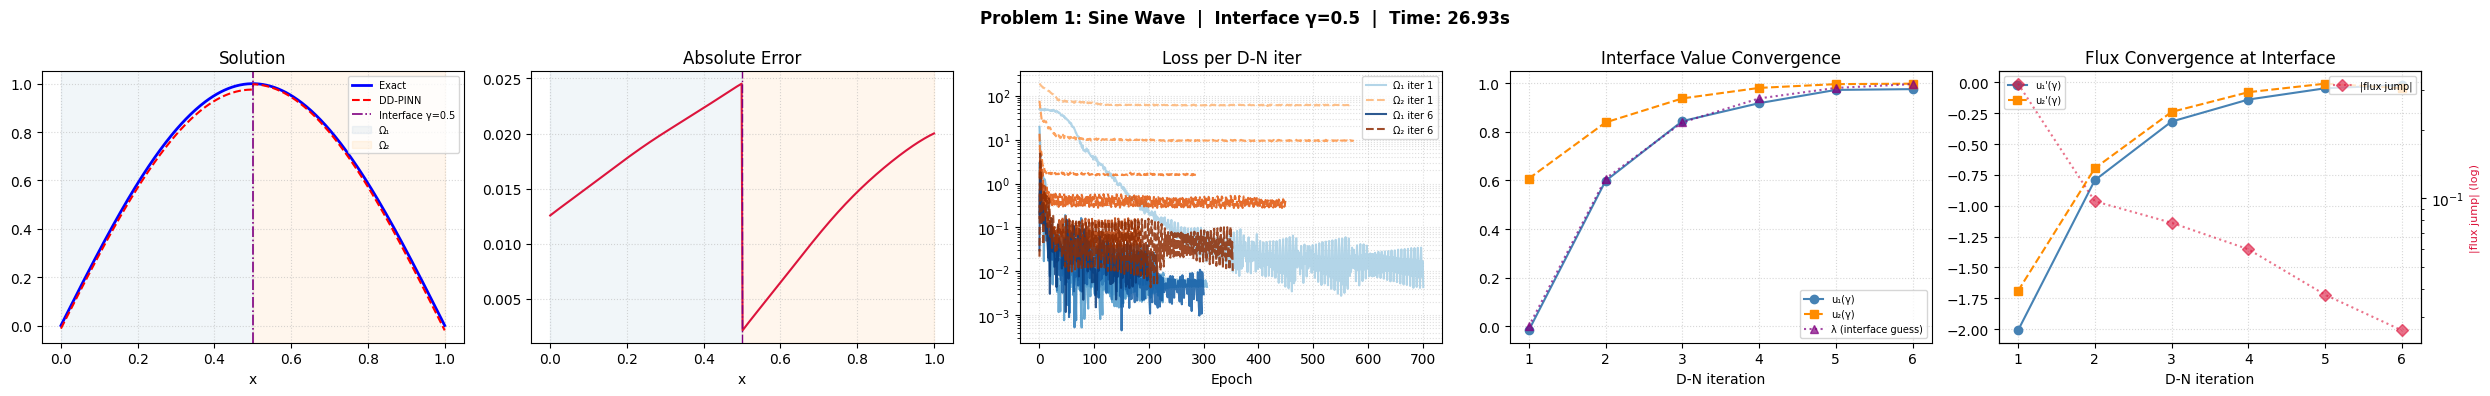

In [9]:
torch.manual_seed(42)
problem_name = "Problem 1: Sine Wave"

f      = lambda x: (torch.pi**2) * torch.sin(torch.pi * x)
exact  = lambda x: torch.sin(torch.pi * x)
bc_l   = (0.0, 0.0)
bc_r   = (1.0, 0.0)

# True interface value for reference
true_gamma_val = float(exact(torch.tensor([[GAMMA]])).item())
print(f"True u(γ={GAMMA}) = {true_gamma_val:.6f}  ← λ should converge here\n")

net1, net2, ilog, elapsed, lhist = dirichlet_neumann_dd(
    f, bc_l, bc_r,
    gamma=GAMMA, dd_iters=DD_ITERS,
    epochs_per_iter=EPOCHS_PER_ITER,
    n_collocation=N_COLL,
    lambda_bc=LAMBDA_BC, lambda_flux=LAMBDA_FLUX,
    lr=LR, patience=PATIENCE, theta=THETA
)
# ── Per-iteration training summary (mirrors overlapping notebook style) ──────
print("\n" + "─"*78)
print(f"  {'Iter':>4}  {'Ω₁ Epochs':>10}  {'Ω₁ Time(s)':>10}  {'Ω₁ Final Loss':>14}  "
      f"{'Ω₂ Epochs':>10}  {'Ω₂ Time(s)':>10}  {'Ω₂ Final Loss':>14}")
print("─"*78)
total_epochs_1 = 0; total_epochs_2 = 0
for k, (h1, h2) in enumerate(zip(lhist['omega1'], lhist['omega2'])):
    total_epochs_1 += len(h1); total_epochs_2 += len(h2)
    # Approximate per-iter time from total elapsed and number of iters
    t_per = elapsed / (2 * len(lhist['omega1']))
    print(f"  {k+1:>4}  {len(h1):>10}  {t_per:>10.2f}  {h1[-1]:>14.6f}  "
          f"{len(h2):>10}  {t_per:>10.2f}  {h2[-1]:>14.6f}")
print("─"*78)
print(f"  {'TOTAL':>4}  {total_epochs_1:>10}  {'':>10}  {'':>14}  "
      f"{total_epochs_2:>10}  {'':>10}  {'':>14}")
print(f"\n  Total Training Time  : {elapsed:.2f}s")
print(f"  Total Epochs (Ω₁)   : {total_epochs_1}  "
      f"(max {DD_ITERS}×{EPOCHS_PER_ITER} = {DD_ITERS*EPOCHS_PER_ITER}, "
      f"early-stopping may reduce)")
print(f"  Total Epochs (Ω₂)   : {total_epochs_2}  "
      f"(max {DD_ITERS}×{EPOCHS_PER_ITER} = {DD_ITERS*EPOCHS_PER_ITER})")
print(f"  Final Loss  (Ω₁)    : {lhist['omega1'][-1][-1]:.6f}")
print(f"  Final Loss  (Ω₂)    : {lhist['omega2'][-1][-1]:.6f}")
print("─"*78)
print("\nEvaluation:")
x, u_pred, u_exact, err, metrics = evaluate_dd(net1, net2, exact, GAMMA)
timing_records.append({'problem': problem_name, 'train_time_s': elapsed, **metrics})
plot_dd(x, u_pred, u_exact, err, lhist, ilog, GAMMA, problem_name, elapsed)

## Problem 2 — Simple Polynomial
$$-u'' = 2, \quad u(0)=0,\ u(1)=0, \quad \text{Exact: } u(x)=x(1-x)$$

True value at interface: $u(0.5) = 0.5 \times 0.5 = 0.25$. True flux: $u'(x) = 1-2x$, so $u'(0.5) = 0$.

True u(γ)  = 0.250000
True u'(γ) = 0.000000  (flux should converge here)


── D-N Iteration 1/6  (λ = 0.000000) ──
  PINN₁ (800 epochs, 3.53s) | 
    u₁(γ) = 0.005814  |  u₁'(γ) = -0.486812  |  loss = 3.12e-02
  PINN₂ (469 epochs, 2.69s) | 
    u₂(γ) = 0.150483  |  u₂'(γ) = -0.407810  |  loss = 3.72e+00
  Interface: |u₁-u₂| = 1.45e-01  |  |u₁'-u₂'| = 7.90e-02
  λ update: 0.000000 → 0.150483

── D-N Iteration 2/6  (λ = 0.150483) ──
  PINN₁ (584 epochs, 2.65s) | 
    u₁(γ) = 0.161236  |  u₁'(γ) = -0.184801  |  loss = 1.01e-02
  PINN₂ (298 epochs, 1.51s) | 
    u₂(γ) = 0.210592  |  u₂'(γ) = -0.150731  |  loss = 5.93e-01
  Interface: |u₁-u₂| = 4.94e-02  |  |u₁'-u₂'| = 3.41e-02
  λ update: 0.150483 → 0.210592

── D-N Iteration 3/6  (λ = 0.210592) ──
  PINN₁ (264 epochs, 1.33s) | 
    u₁(γ) = 0.198167  |  u₁'(γ) = -0.082468  |  loss = 1.15e-02
  PINN₂ (540 epochs, 2.93s) | 
    u₂(γ) = 0.226465  |  u₂'(γ) = -0.086350  |  loss = 1.17e-01
  Interface: |u₁-u₂| = 2.83e-02  |  |u₁'-u₂'| = 3.88e-0

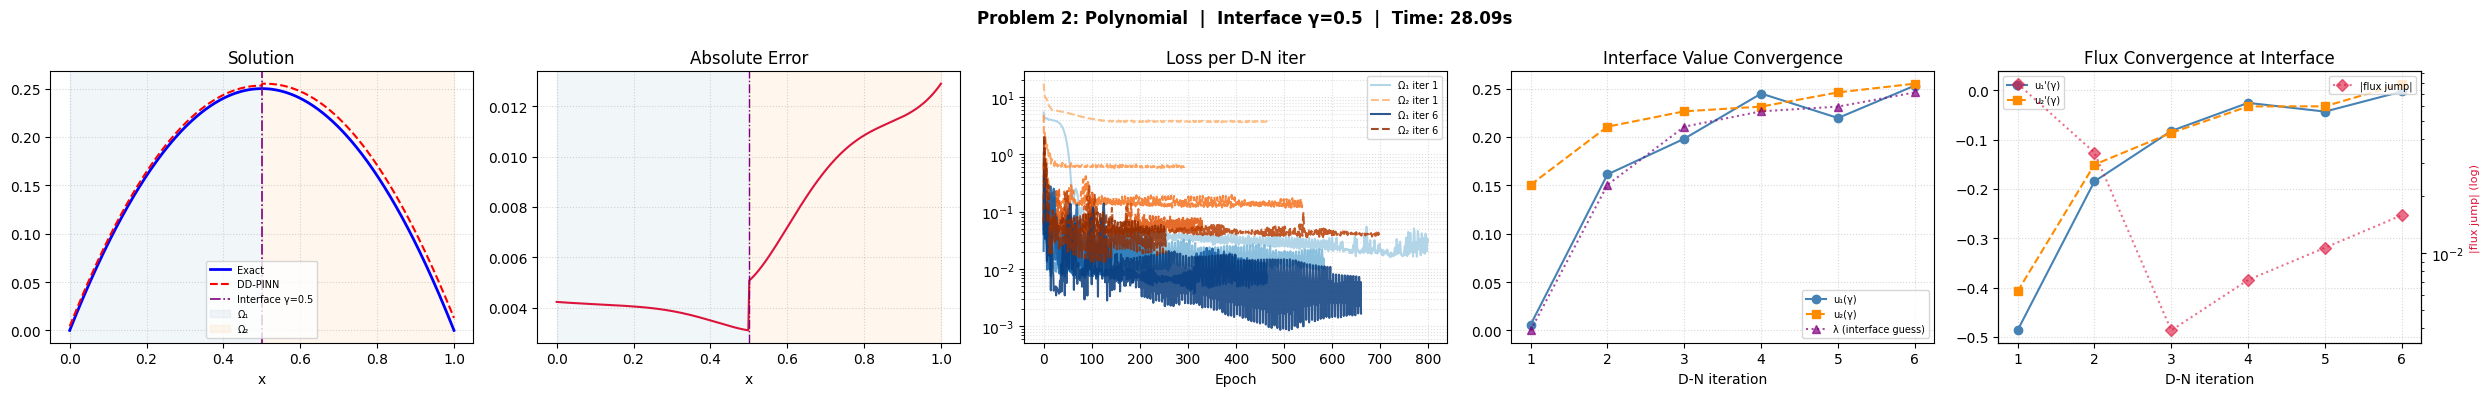

In [10]:
torch.manual_seed(42)
problem_name = "Problem 2: Polynomial"

f      = lambda x: 2.0 * torch.ones_like(x)
exact  = lambda x: x * (1 - x)
bc_l   = (0.0, 0.0)
bc_r   = (1.0, 0.0)

true_gamma_val = float(exact(torch.tensor([[GAMMA]])).item())
true_flux_val  = 1.0 - 2.0 * GAMMA   # u'(x) = 1-2x
print(f"True u(γ)  = {true_gamma_val:.6f}")
print(f"True u'(γ) = {true_flux_val:.6f}  (flux should converge here)\n")

net1, net2, ilog, elapsed, lhist = dirichlet_neumann_dd(
    f, bc_l, bc_r,
    gamma=GAMMA, dd_iters=DD_ITERS,
    epochs_per_iter=EPOCHS_PER_ITER,
    n_collocation=N_COLL,
    lambda_bc=LAMBDA_BC, lambda_flux=LAMBDA_FLUX,
    lr=LR, patience=PATIENCE, theta=THETA
)
# ── Per-iteration training summary (mirrors overlapping notebook style) ──────
print("\n" + "─"*78)
print(f"  {'Iter':>4}  {'Ω₁ Epochs':>10}  {'Ω₁ Time(s)':>10}  {'Ω₁ Final Loss':>14}  "
      f"{'Ω₂ Epochs':>10}  {'Ω₂ Time(s)':>10}  {'Ω₂ Final Loss':>14}")
print("─"*78)
total_epochs_1 = 0; total_epochs_2 = 0
for k, (h1, h2) in enumerate(zip(lhist['omega1'], lhist['omega2'])):
    total_epochs_1 += len(h1); total_epochs_2 += len(h2)
    # Approximate per-iter time from total elapsed and number of iters
    t_per = elapsed / (2 * len(lhist['omega1']))
    print(f"  {k+1:>4}  {len(h1):>10}  {t_per:>10.2f}  {h1[-1]:>14.6f}  "
          f"{len(h2):>10}  {t_per:>10.2f}  {h2[-1]:>14.6f}")
print("─"*78)
print(f"  {'TOTAL':>4}  {total_epochs_1:>10}  {'':>10}  {'':>14}  "
      f"{total_epochs_2:>10}  {'':>10}  {'':>14}")
print(f"\n  Total Training Time  : {elapsed:.2f}s")
print(f"  Total Epochs (Ω₁)   : {total_epochs_1}  "
      f"(max {DD_ITERS}×{EPOCHS_PER_ITER} = {DD_ITERS*EPOCHS_PER_ITER}, "
      f"early-stopping may reduce)")
print(f"  Total Epochs (Ω₂)   : {total_epochs_2}  "
      f"(max {DD_ITERS}×{EPOCHS_PER_ITER} = {DD_ITERS*EPOCHS_PER_ITER})")
print(f"  Final Loss  (Ω₁)    : {lhist['omega1'][-1][-1]:.6f}")
print(f"  Final Loss  (Ω₂)    : {lhist['omega2'][-1][-1]:.6f}")
print("─"*78)
print("\nEvaluation:")
x, u_pred, u_exact, err, metrics = evaluate_dd(net1, net2, exact, GAMMA)
timing_records.append({'problem': problem_name, 'train_time_s': elapsed, **metrics})
plot_dd(x, u_pred, u_exact, err, lhist, ilog, GAMMA, problem_name, elapsed)

## Problem 3 — High-Frequency Sine
$$-u'' = 4\pi^2\sin(2\pi x), \quad u(0)=0,\ u(1)=0, \quad \text{Exact: } u(x)=\sin(2\pi x)$$

True value at interface: $\sin(2\pi \cdot 0.5) = \sin(\pi) = 0$.  
True flux: $u'(x) = 2\pi\cos(2\pi x)$, so $u'(0.5) = 2\pi\cos(\pi) = -2\pi \approx -6.283$.

This is the hardest problem due to spectral bias. The flux jump convergence is the most informative panel here.

True u(γ)  = -0.000000
True u'(γ) = -6.283185


── D-N Iteration 1/6  (λ = 0.000000) ──
  PINN₁ (800 epochs, 4.53s) | 
    u₁(γ) = -0.011369  |  u₁'(γ) = -6.294803  |  loss = 1.62e-02
  PINN₂ (550 epochs, 3.12s) | 
    u₂(γ) = 0.004308  |  u₂'(γ) = -6.285402  |  loss = 5.20e-02
  Interface: |u₁-u₂| = 1.57e-02  |  |u₁'-u₂'| = 9.40e-03
  λ update: 0.000000 → 0.004308

── D-N Iteration 2/6  (λ = 0.004308) ──
  PINN₁ (303 epochs, 1.52s) | 
    u₁(γ) = 0.051053  |  u₁'(γ) = -6.253396  |  loss = 1.33e-01
  PINN₂ (588 epochs, 3.21s) | 
    u₂(γ) = 0.001269  |  u₂'(γ) = -6.244641  |  loss = 5.07e-02
  Interface: |u₁-u₂| = 4.98e-02  |  |u₁'-u₂'| = 8.76e-03
  λ update: 0.004308 → 0.001269

── D-N Iteration 3/6  (λ = 0.001269) ──
  PINN₁ (188 epochs, 0.76s) | 
    u₁(γ) = 0.009055  |  u₁'(γ) = -6.282985  |  loss = 9.09e-02
  PINN₂ (361 epochs, 1.72s) | 
    u₂(γ) = 0.004317  |  u₂'(γ) = -6.273365  |  loss = 3.72e-02
  Interface: |u₁-u₂| = 4.74e-03  |  |u₁'-u₂'| = 9.62e-03
  λ update: 0.001269 → 0

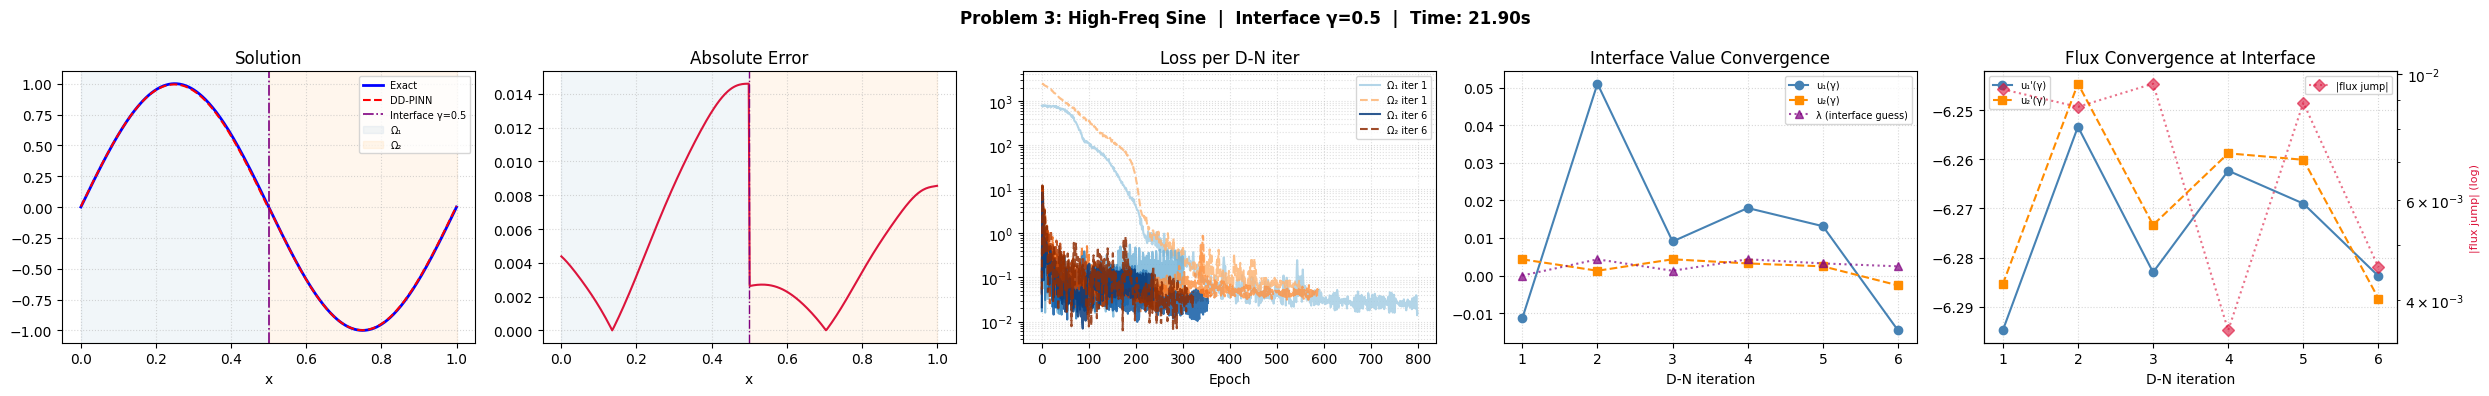

In [11]:
torch.manual_seed(42)
problem_name = "Problem 3: High-Freq Sine"

f      = lambda x: (4 * torch.pi**2) * torch.sin(2 * torch.pi * x)
exact  = lambda x: torch.sin(2 * torch.pi * x)
bc_l   = (0.0, 0.0)
bc_r   = (1.0, 0.0)

true_gamma_val = float(exact(torch.tensor([[GAMMA]])).item())
true_flux_val  = float(2 * np.pi * np.cos(2 * np.pi * GAMMA))
print(f"True u(γ)  = {true_gamma_val:.6f}")
print(f"True u'(γ) = {true_flux_val:.6f}\n")

net1, net2, ilog, elapsed, lhist = dirichlet_neumann_dd(
    f, bc_l, bc_r,
    gamma=GAMMA, dd_iters=DD_ITERS,
    epochs_per_iter=EPOCHS_PER_ITER,
    n_collocation=N_COLL,
    lambda_bc=LAMBDA_BC, lambda_flux=LAMBDA_FLUX,
    lr=LR, patience=PATIENCE, theta=THETA
)
# ── Per-iteration training summary (mirrors overlapping notebook style) ──────
print("\n" + "─"*78)
print(f"  {'Iter':>4}  {'Ω₁ Epochs':>10}  {'Ω₁ Time(s)':>10}  {'Ω₁ Final Loss':>14}  "
      f"{'Ω₂ Epochs':>10}  {'Ω₂ Time(s)':>10}  {'Ω₂ Final Loss':>14}")
print("─"*78)
total_epochs_1 = 0; total_epochs_2 = 0
for k, (h1, h2) in enumerate(zip(lhist['omega1'], lhist['omega2'])):
    total_epochs_1 += len(h1); total_epochs_2 += len(h2)
    # Approximate per-iter time from total elapsed and number of iters
    t_per = elapsed / (2 * len(lhist['omega1']))
    print(f"  {k+1:>4}  {len(h1):>10}  {t_per:>10.2f}  {h1[-1]:>14.6f}  "
          f"{len(h2):>10}  {t_per:>10.2f}  {h2[-1]:>14.6f}")
print("─"*78)
print(f"  {'TOTAL':>4}  {total_epochs_1:>10}  {'':>10}  {'':>14}  "
      f"{total_epochs_2:>10}  {'':>10}  {'':>14}")
print(f"\n  Total Training Time  : {elapsed:.2f}s")
print(f"  Total Epochs (Ω₁)   : {total_epochs_1}  "
      f"(max {DD_ITERS}×{EPOCHS_PER_ITER} = {DD_ITERS*EPOCHS_PER_ITER}, "
      f"early-stopping may reduce)")
print(f"  Total Epochs (Ω₂)   : {total_epochs_2}  "
      f"(max {DD_ITERS}×{EPOCHS_PER_ITER} = {DD_ITERS*EPOCHS_PER_ITER})")
print(f"  Final Loss  (Ω₁)    : {lhist['omega1'][-1][-1]:.6f}")
print(f"  Final Loss  (Ω₂)    : {lhist['omega2'][-1][-1]:.6f}")
print("─"*78)
print("\nEvaluation:")
x, u_pred, u_exact, err, metrics = evaluate_dd(net1, net2, exact, GAMMA)
timing_records.append({'problem': problem_name, 'train_time_s': elapsed, **metrics})
plot_dd(x, u_pred, u_exact, err, lhist, ilog, GAMMA, problem_name, elapsed)

## Problem 4 — Exponential (Non-Zero BCs)
$$-u'' = -e^x, \quad u(0)=1,\ u(1)=e, \quad \text{Exact: } u(x)=e^x$$

True value at interface: $e^{0.5} \approx 1.6487$.  
True flux: $u'(x) = e^x$, so $u'(0.5) = e^{0.5} \approx 1.6487$.

Non-zero BCs test whether the interface update handles non-homogeneous problems correctly.

True u(γ)  = 1.648721
True u'(γ) = 1.648721  (equal since u'=u=eˣ)


── D-N Iteration 1/6  (λ = 1.859141) ──
  PINN₁ (516 epochs, 2.40s) | 
    u₁(γ) = 1.831401  |  u₁'(γ) = 2.059984  |  loss = 7.88e-02
  PINN₂ (800 epochs, 4.42s) | 
    u₂(γ) = 1.703335  |  u₂'(γ) = 1.973185  |  loss = 3.11e+00
  Interface: |u₁-u₂| = 1.28e-01  |  |u₁'-u₂'| = 8.68e-02
  λ update: 1.859141 → 1.703335

── D-N Iteration 2/6  (λ = 1.703335) ──
  PINN₁ (327 epochs, 1.54s) | 
    u₁(γ) = 1.705650  |  u₁'(γ) = 1.780336  |  loss = 1.16e-02
  PINN₂ (554 epochs, 2.80s) | 
    u₂(γ) = 1.645913  |  u₂'(γ) = 1.741674  |  loss = 2.96e-01
  Interface: |u₁-u₂| = 5.97e-02  |  |u₁'-u₂'| = 3.87e-02
  λ update: 1.703335 → 1.645913

── D-N Iteration 3/6  (λ = 1.645913) ──
  PINN₁ (358 epochs, 1.47s) | 
    u₁(γ) = 1.662827  |  u₁'(γ) = 1.650164  |  loss = 3.16e-02
  PINN₂ (185 epochs, 0.97s) | 
    u₂(γ) = 1.619883  |  u₂'(γ) = 1.621210  |  loss = 3.23e-02
  Interface: |u₁-u₂| = 4.29e-02  |  |u₁'-u₂'| = 2.90e-02
  λ update

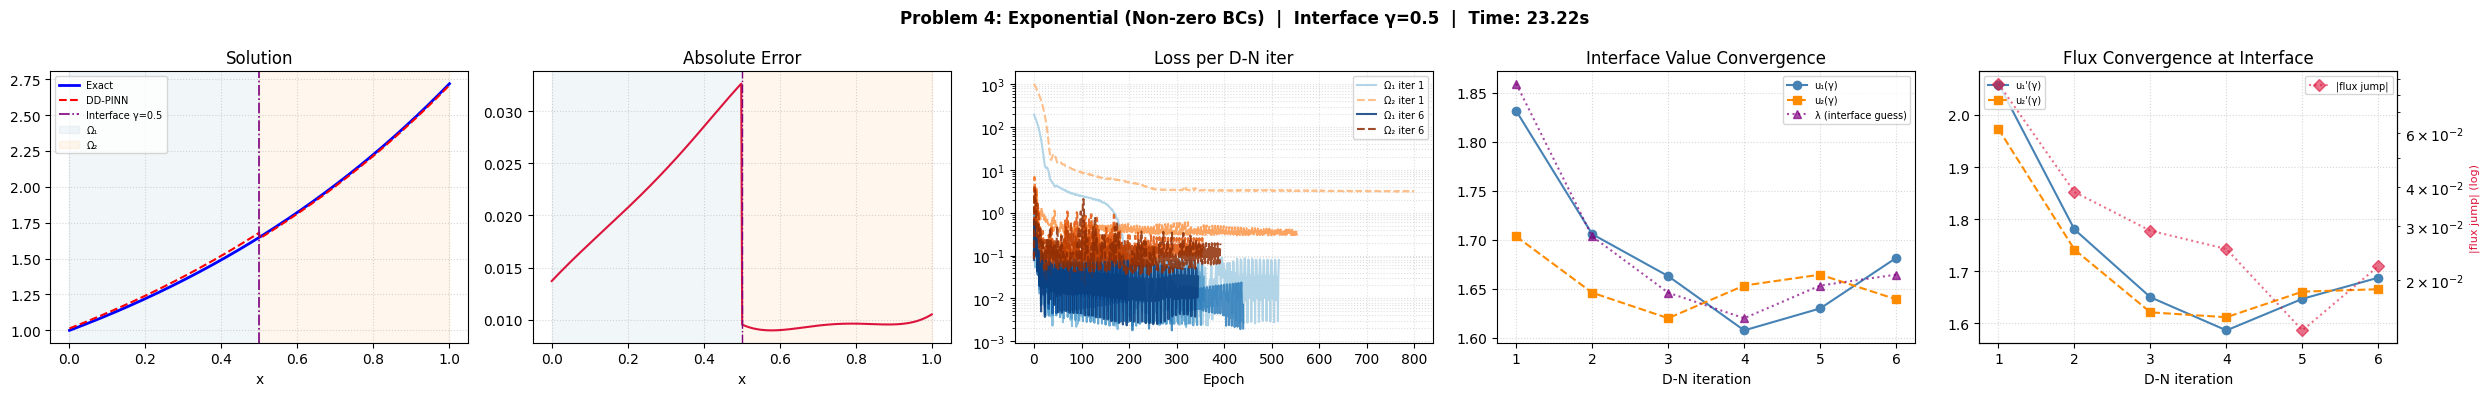

In [12]:
torch.manual_seed(42)
problem_name = "Problem 4: Exponential (Non-zero BCs)"

f      = lambda x: -torch.exp(x)
exact  = lambda x: torch.exp(x)
bc_l   = (0.0, 1.0)
bc_r   = (1.0, float(np.e))

true_gamma_val = float(np.exp(GAMMA))
true_flux_val  = float(np.exp(GAMMA))   # u' = u = e^x
print(f"True u(γ)  = {true_gamma_val:.6f}")
print(f"True u'(γ) = {true_flux_val:.6f}  (equal since u'=u=eˣ)\n")

net1, net2, ilog, elapsed, lhist = dirichlet_neumann_dd(
    f, bc_l, bc_r,
    gamma=GAMMA, dd_iters=DD_ITERS,
    epochs_per_iter=EPOCHS_PER_ITER,
    n_collocation=N_COLL,
    lambda_bc=LAMBDA_BC, lambda_flux=LAMBDA_FLUX,
    lr=LR, patience=PATIENCE, theta=THETA
)
# ── Per-iteration training summary (mirrors overlapping notebook style) ──────
print("\n" + "─"*78)
print(f"  {'Iter':>4}  {'Ω₁ Epochs':>10}  {'Ω₁ Time(s)':>10}  {'Ω₁ Final Loss':>14}  "
      f"{'Ω₂ Epochs':>10}  {'Ω₂ Time(s)':>10}  {'Ω₂ Final Loss':>14}")
print("─"*78)
total_epochs_1 = 0; total_epochs_2 = 0
for k, (h1, h2) in enumerate(zip(lhist['omega1'], lhist['omega2'])):
    total_epochs_1 += len(h1); total_epochs_2 += len(h2)
    # Approximate per-iter time from total elapsed and number of iters
    t_per = elapsed / (2 * len(lhist['omega1']))
    print(f"  {k+1:>4}  {len(h1):>10}  {t_per:>10.2f}  {h1[-1]:>14.6f}  "
          f"{len(h2):>10}  {t_per:>10.2f}  {h2[-1]:>14.6f}")
print("─"*78)
print(f"  {'TOTAL':>4}  {total_epochs_1:>10}  {'':>10}  {'':>14}  "
      f"{total_epochs_2:>10}  {'':>10}  {'':>14}")
print(f"\n  Total Training Time  : {elapsed:.2f}s")
print(f"  Total Epochs (Ω₁)   : {total_epochs_1}  "
      f"(max {DD_ITERS}×{EPOCHS_PER_ITER} = {DD_ITERS*EPOCHS_PER_ITER}, "
      f"early-stopping may reduce)")
print(f"  Total Epochs (Ω₂)   : {total_epochs_2}  "
      f"(max {DD_ITERS}×{EPOCHS_PER_ITER} = {DD_ITERS*EPOCHS_PER_ITER})")
print(f"  Final Loss  (Ω₁)    : {lhist['omega1'][-1][-1]:.6f}")
print(f"  Final Loss  (Ω₂)    : {lhist['omega2'][-1][-1]:.6f}")
print("─"*78)
print("\nEvaluation:")
x, u_pred, u_exact, err, metrics = evaluate_dd(net1, net2, exact, GAMMA)
timing_records.append({'problem': problem_name, 'train_time_s': elapsed, **metrics})
plot_dd(x, u_pred, u_exact, err, lhist, ilog, GAMMA, problem_name, elapsed)

## Section 9 — Effect of Relaxation Parameter θ

The relaxation parameter $\theta$ in:
$$\lambda^{(k+1)} = \theta \cdot u_2(\gamma) + (1-\theta) \cdot \lambda^{(k)}$$

controls how aggressively the interface is updated each iteration.

- $\theta = 1.0$: full update (aggressive, may oscillate for some problems)
- $\theta = 0.5$: half update (conservative, more stable but slower)
- $\theta = 0.8$: typical compromise

This study runs Problem 1 with three values of θ and compares final accuracy.


  θ = 1.0
  Relative L2 Error  : 0.023334
  Max Absolute Error : 0.024520
  Mean Absolute Error: 0.015507

  θ = 0.8
  Relative L2 Error  : 0.034298
  Max Absolute Error : 0.051796
  Mean Absolute Error: 0.019770

  θ = 0.5
  Relative L2 Error  : 0.116371
  Max Absolute Error : 0.151794
  Mean Absolute Error: 0.075579


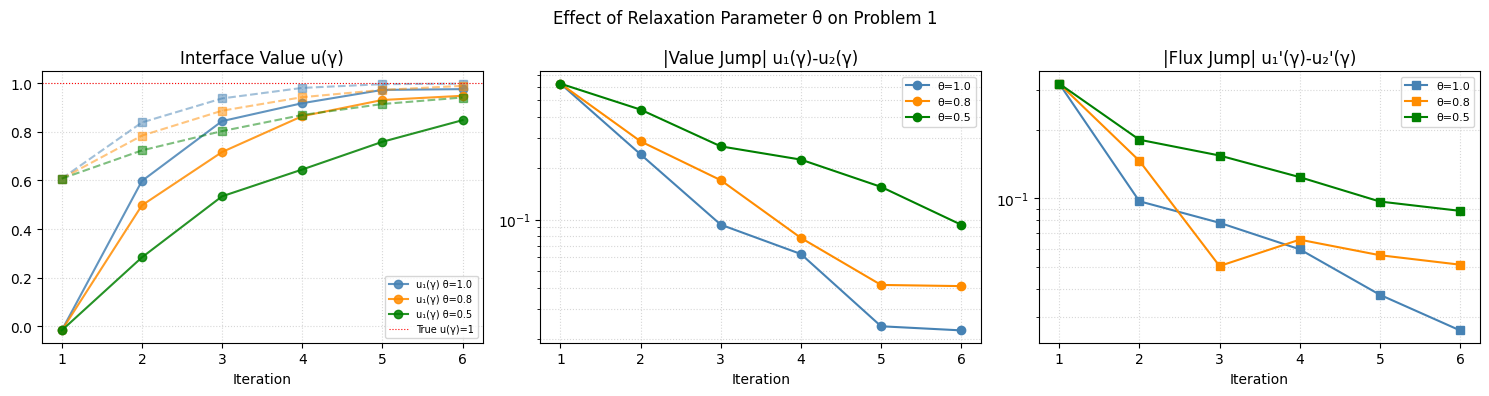


Final Rel L2 errors:
  θ=1.0:  Rel L2 = 0.023334
  θ=0.8:  Rel L2 = 0.034298
  θ=0.5:  Rel L2 = 0.116371


In [13]:
torch.manual_seed(42)
f_s     = lambda x: (torch.pi**2) * torch.sin(torch.pi * x)
exact_s = lambda x: torch.sin(torch.pi * x)
bc_l_s  = (0.0, 0.0)
bc_r_s  = (1.0, 0.0)

theta_values = [1.0, 0.8, 0.5]
theta_results = {}

for th in theta_values:
    print(f"\n{'='*45}")
    print(f"  θ = {th}")
    print('='*45)
    torch.manual_seed(42)
    n1, n2, ilog_th, el_th, lh_th = dirichlet_neumann_dd(
        f_s, bc_l_s, bc_r_s,
        gamma=GAMMA, dd_iters=DD_ITERS,
        epochs_per_iter=EPOCHS_PER_ITER,
        n_collocation=N_COLL,
        lambda_bc=LAMBDA_BC, lambda_flux=LAMBDA_FLUX,
        lr=LR, patience=PATIENCE, theta=th, verbose=False
    )
    _, _, _, _, m = evaluate_dd(n1, n2, exact_s, GAMMA)
    theta_results[th] = {
        'ilog': ilog_th, 'metrics': m, 'elapsed': el_th
    }

# Comparison plot
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Effect of Relaxation Parameter θ on Problem 1", fontsize=12)

colors = {'1.0': 'steelblue', '0.8': 'darkorange', '0.5': 'green'}
for th, res in theta_results.items():
    ilog_th = res['ilog']
    iters   = [v['iter']    for v in ilog_th]
    u1g     = [v['u1_gamma'] for v in ilog_th]
    u2g     = [v['u2_gamma'] for v in ilog_th]
    jmp     = [v['value_jump'] for v in ilog_th]
    fl_jmp  = [v['flux_jump']  for v in ilog_th]
    c       = colors[str(th)]

    axs[0].plot(iters, u1g, 'o-', color=c, label=f'u₁(γ) θ={th}', alpha=0.85)
    axs[0].plot(iters, u2g, 's--',color=c, alpha=0.5)
    axs[1].semilogy(iters, jmp, 'o-', color=c, label=f'θ={th}')
    axs[2].semilogy(iters, fl_jmp, 's-', color=c, label=f'θ={th}')

axs[0].axhline(y=1.0, color='red', lw=0.8, linestyle=':', label='True u(γ)=1')
axs[0].set_title('Interface Value u(γ)'); axs[0].set_xlabel('Iteration')
axs[0].legend(fontsize=7); axs[0].grid(True, linestyle=':', alpha=0.5)

axs[1].set_title('|Value Jump| u₁(γ)-u₂(γ)'); axs[1].set_xlabel('Iteration')
axs[1].legend(fontsize=8); axs[1].grid(True, which='both', linestyle=':', alpha=0.5)

axs[2].set_title("|Flux Jump| u₁'(γ)-u₂'(γ)"); axs[2].set_xlabel('Iteration')
axs[2].legend(fontsize=8); axs[2].grid(True, which='both', linestyle=':', alpha=0.5)

plt.tight_layout(); plt.show()

print("\nFinal Rel L2 errors:")
for th, res in theta_results.items():
    print(f"  θ={th}:  Rel L2 = {res['metrics']['rel_l2']:.6f}")

## Section 10 — Effect of Flux Penalty Weight λ_flux

$\lambda_{\text{flux}}$ controls how strongly PINN₂ is pushed to match the flux $u_1'(\gamma)$ from PINN₁.

- Too small → PINN₂ ignores flux information → poor continuity of derivatives
- Too large → flux term dominates, PDE residual ignored → inaccurate interior solution
- Typical range: $[10, 100]$

  Relative L2 Error  : 0.216002
  Max Absolute Error : 0.255715
  Mean Absolute Error: 0.141020
  λ_flux=   5.0: Rel L2 = 2.1600e-01
  Relative L2 Error  : 0.090434
  Max Absolute Error : 0.122258
  Mean Absolute Error: 0.059045
  λ_flux=  25.0: Rel L2 = 9.0434e-02
  Relative L2 Error  : 0.056436
  Max Absolute Error : 0.076578
  Mean Absolute Error: 0.036845
  λ_flux=  50.0: Rel L2 = 5.6436e-02
  Relative L2 Error  : 0.060345
  Max Absolute Error : 0.071015
  Mean Absolute Error: 0.040331
  λ_flux= 100.0: Rel L2 = 6.0345e-02
  Relative L2 Error  : 0.051384
  Max Absolute Error : 0.057406
  Mean Absolute Error: 0.034107
  λ_flux= 200.0: Rel L2 = 5.1384e-02


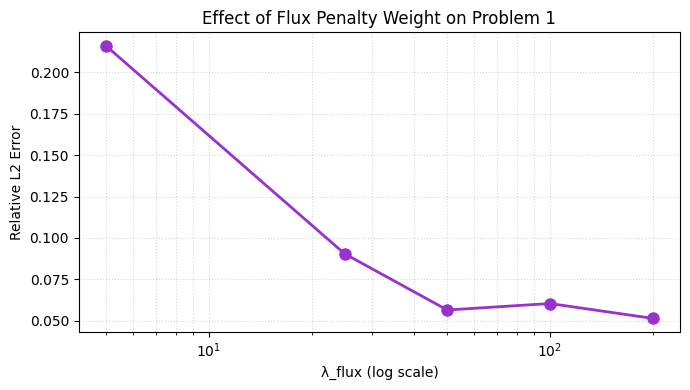

In [14]:
flux_weights = [5.0, 25.0, 50.0, 100.0, 200.0]
flux_results = {}

for lf in flux_weights:
    torch.manual_seed(42)
    n1, n2, _, _, _ = dirichlet_neumann_dd(
        f_s, bc_l_s, bc_r_s,
        gamma=GAMMA, dd_iters=4,
        epochs_per_iter=600, n_collocation=N_COLL,
        lambda_bc=LAMBDA_BC, lambda_flux=lf,
        lr=LR, patience=PATIENCE, theta=THETA, verbose=False
    )
    _, _, _, _, m = evaluate_dd(n1, n2, exact_s, GAMMA)
    flux_results[lf] = m['rel_l2']
    print(f"  λ_flux={lf:>6.1f}: Rel L2 = {m['rel_l2']:.4e}")

plt.figure(figsize=(7, 4))
plt.semilogx(list(flux_results.keys()), list(flux_results.values()),
             'o-', color='darkorchid', markersize=8, linewidth=2)
plt.xlabel('λ_flux (log scale)')
plt.ylabel('Relative L2 Error')
plt.title('Effect of Flux Penalty Weight on Problem 1')
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.tight_layout(); plt.show()

## Section 11 — Summary Table

In [15]:
print("\n" + "="*78)
print(f"{'Problem':<40} {'Time(s)':>8} {'Max Err':>10} {'Mean Err':>10} {'Rel L2':>9}")
print("="*78)
for r in timing_records:
    print(f"{r['problem']:<40} {r['train_time_s']:>8.2f} "
          f"{r['max_err']:>10.6f} {r['mean_err']:>10.6f} {r['rel_l2']:>9.6f}")
print("="*78)
total = sum(r['train_time_s'] for r in timing_records)
print(f"{'TOTAL':.<40} {total:>8.2f}")


Problem                                   Time(s)    Max Err   Mean Err    Rel L2
Problem 1: Sine Wave                        26.93   0.024520   0.015507  0.023334
Problem 2: Polynomial                       28.09   0.012896   0.006724  0.041062
Problem 3: High-Freq Sine                   21.90   0.014601   0.005398  0.009747
Problem 4: Exponential (Non-zero BCs)       23.22   0.032627   0.016139  0.009999
TOTAL...................................   100.13


## Section 12 — Comparison: Overlapping vs Non-Overlapping

| Feature | Overlapping (Schwarz) | Non-Overlapping (D-N) |
|---------|----------------------|----------------------|
| Interface | Overlap zone $[a,b]$ | Single point $\gamma$ |
| Info transferred | Value only (Dirichlet) | Value + flux (Dirichlet + Neumann) |
| Extra loss term | None | $\lambda_{\text{flux}}\cdot(u_2'(\gamma) - u_1'(\gamma))^2$ |
| Convergence metric | Interface value jump | **Both** value jump and flux jump |
| Stitching | Blend in overlap zone | Clean partition |
| Typically better for | Simple problems | Physically correct flux conservation |

**Key insight for your SRIP project:**

Non-overlapping DD is more physically meaningful for the Linearized Poisson-Boltzmann equation because:
- In electrostatics, the **normal flux** $\partial u/\partial n$ represents the electric field component
- Physical conservation requires both $u$ and $\partial u/\partial n$ to be **continuous** across subdomain interfaces
- The overlapping method only enforces value continuity — the non-overlapping D-N method enforces **both**

This makes the non-overlapping approach the correct foundation for the LPB and COSMO applications in Phase 4.